
# Bai thuc hanh so 8 - Phan 1: MÔ HÌNH ANN (MULTI LAYER PERCEPTRON CLASSIFIER VÀ ỨNG DỤNG PCA)
- Trong phần thực hành này, chúng ta sẽ bắt đầu với việc xây dựng mô hình ANN bằng các bước như lý thuyết,
chỉ với các công cụ cơ bản (numpy) và thực hiện trên tập dữ liệu nhân tạo. Sau đó chúng ta sẽ dùng PCA để
giảm số chiều của một vài tập dữ liệu thực tế và áp dụng mô hình ANN của chúng ta để phân lớp.


## Vi du 1: 
- Ý tưởng ví dụ này tham khảo từ https://cs231n.github.io/neural-networks-case-study/ , với dữ liệu
nhân tạo để minh họa (toy example).
- Trước hết chúng ta tạo một tập dữ liệu được chia vào 03 phân lớp khác nhau trong không gian d =2 chiều
(để có thể hiển thị ra mặt phẳng). Các phân lớp sẽ được tạo sao cho không có hai phân lớp nào là tách được
tuyến tính (linearly separable). Đoạn lệnh dưới đây để tạo dữ liệu theo ý tưởng như vậ

In [38]:
# import the necessary libraries
from __future__ import division, print_function, unicode_literals
import math
import numpy as np
import matplotlib.pyplot as plt 

In [39]:
N = 200 # number of points per class
d = 2 # dimensionality
C = 3 # number of classes
X = np.zeros((d, N*C)) # data matrix (each row = single example)
y = np.zeros(N*C, dtype='uint8') # class labels

for j in range(C):
    ix = range(N*j,N*(j+1))
    r = np.linspace(0.0,1,N) # radius
    # goc quay cua cac diem 
    t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 #  
    # chuyen doi tu he tao do cuc sang he toa do decat 
    X[:,ix] = np.c_[r*np.sin(t), r*np.cos(t)].T
    y[ix] = j

- Trong đoạn lệnh trên, ta đã tạo dữ liệu (là các điểm – 2 chiều) bằng cách tạo các điểm theo tọa độ cực: từ
một tâm điểm, ta vừa tăng dần bán kính r, đồng thời tăng dần góc t theo chỉ số của điểm, dẫn đến các điểm
sẽ được phân bố xa dần tâm và tạo thành vệt xoáy. Ngoài ra ta bổ sung yếu tố ngẫu nhiên
np.random.randn(N)*0.2 để tọa độ các điểm có sự xê dịch xung quanh vệt xoáy.

- Truc quan hoa du lieu

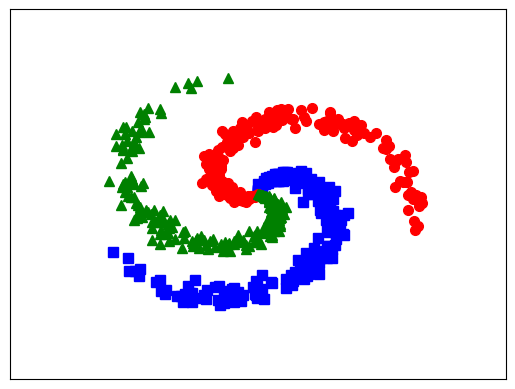

In [40]:
# lets visualize the data:
plt.plot(X[0, :N], X[1, :N], 'bs', markersize = 7);
plt.plot(X[0, N:2*N], X[1, N:2*N], 'ro', markersize = 7);
plt.plot(X[0, 2*N:], X[1, 2*N:], 'g^', markersize = 7);
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
# lam sach truc toa do 
cur_axes = plt.gca() # lay he truc toa do hien tai 
# set_ticks([]) truyen vao mot mang rong de xoa het vach chia tren he truc toa do
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
plt.savefig('example_points.png', bbox_inches='tight', dpi = 600)
plt.show()

- Do ở đây dữ liệu không tách được tuyến tính, nên chúng ta không thể sử dụng phương pháp hồi quy Softmax.
Dưới đây chúng ta sử dụng một kiến trúc mạng ANN với 01 tầng ẩn bổ sung (tức số Layer L = 2), và ở tầng
đầu ra (output) chúng ta sử dụng hàm kích hoạt là SoftMax, do đây là bài toán phân loại nhiều lớp


In [41]:
# xay dung ham softmax
def softmax(V):
    e_V = np.exp(V - np.max(V, axis = 0, keepdims = True))
    Z = e_V / e_V.sum(axis = 0)
    return Z

- Xay dung ham loss, duoc tinh theo cong thuc voi truong hop phan loai nhieu lop bang softmax

In [42]:
def cost(Y, Yhat):
    return -np.sum(Y * np.log(Yhat)) / Y.shape[1]

- Tiếp theo, chúng ta chuyển đầu ra Y từ dạng số nguyên trong tập {1, 2, …, C} - ứng với C classes – sang
dạng onehot-coding, tức là vector C thành phần, nếu Y thuộc lớp thứ c thì tọa độ thứ c tương ứng là 1, các
tọa độ khác là 0

In [43]:
# one - hot coding 
from scipy import sparse
def convert_labels(y, C = 3):
    Y = sparse.coo_matrix((np.ones_like(y), (y, np.arange(len(y)))), 
                        shape = (C, len(y))).toarray()
    return Y


- Tiếp theo ta khởi tạo các giá trị cho bộ trọng số và các số kiến trúc mạng. Ở đây ta sẽ bổ sung 01 tầng hidden
với số units của tầng này là 100. Các bạn có thể tăng hoặc giảm con số này và quan sát kết quả. Ở tầng đầu
ra, chúng ta cần vector 03 thành phần là xác suất để điểm tương ứng rơi vào một trong các lớp 0, 1, 2 (thay
cho 1, 2, 3). Vậy số chiều của các tầng trong mạng ANN sẽ là: d0 = 2 (tầng input); d1 = 100 (tầng hidden)
và d2 = 3 (tầng output). Đoạn lệnh khởi tạo như sau

In [44]:
d0 = 2
d1 = h = 100 # size of hidden layer
d2 = C = 3
# initialize parameters randomly
W1 = 0.01*np.random.randn(d0, d1)
b1 = np.zeros((d1, 1))
W2 = 0.01*np.random.randn(d1, d2)
b2 = np.zeros((d2, 1))

Y = convert_labels(y, C)
N = X.shape[1]
eta = 1 # learning rate

- Tiếp theo là đoạn chương trình thực hiện thuật toán lặp theo phương pháp Gradient Descent

In [45]:
for i in range(10000):
    # feedforward
    Z1 = np.dot(W1.T, X) + b1
    A1 = np.maximum(Z1, 0)
    Z2 = np.dot(W2.T, A1) + b2
    Yhat = softmax(Z2)
    
    # print loss after each 1000 iterations
    if i % 1000 == 0:
        # compute the loss: average cross - entropy loss
        loss = cost(Y, Yhat)
        print("iter %d, loss: %f" %(i, loss))
        
    # backpropagation 
    E2 = (Yhat - Y) / N
    dW2 = np.dot(A1, E2.T)
    db2 = np.sum(E2, axis = 1, keepdims = True)
    E1 = np.dot(W2, E2)
    E1[Z1 <= 0] = 0 # gradient of ReLu
    dW1 = np.dot(X, E1.T)
    db1 = np.sum(E1, axis = 1, keepdims = True)
    
    # gradient descent update
    W1 += -eta*dW1
    b1 += -eta * db1
    W2 += -eta * dW2
    b2 += -eta * db2
    
        

iter 0, loss: 1.098753
iter 1000, loss: 0.136829
iter 2000, loss: 0.048490
iter 3000, loss: 0.032716
iter 4000, loss: 0.026112
iter 5000, loss: 0.022477
iter 6000, loss: 0.020201
iter 7000, loss: 0.018592
iter 8000, loss: 0.017374
iter 9000, loss: 0.016405


In [46]:
# do chinh xac co truong hop ap dung len chinh du lieu training 
Z1 = np.dot(W1.T, X) + b1
A1 = np.maximum(Z1, 0)
Z2 = np.dot(W2.T, A1) + b2
predicted_class = np.argmax(Z2, axis = 0)
acc = 100 * np.mean(predicted_class == y)
print('training accuracy: %.2f %%' % (acc))

training accuracy: 99.67 %


(1, 14400)
100


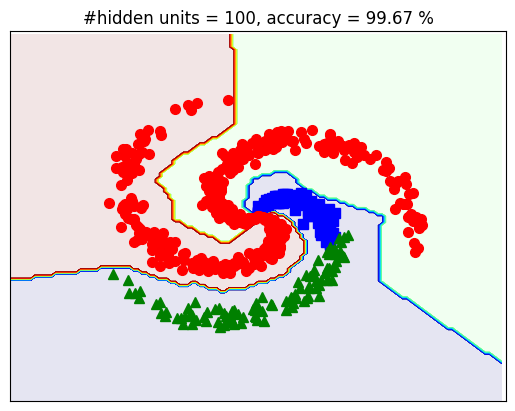

In [47]:
# visualize result
xm = np.arange(-1.5, 1.5, 0.025)
xlen = len(xm)
ym = np.arange(-1.5, 1.5, 0.025)
ylen = len(ym)
xx, yy =  np.meshgrid(xm, ym)

# xx, yy

print(np.ones((1, xx.size)).shape)
xx1 = xx.ravel().reshape(1, xx.size)
yy1 = yy.ravel().reshape(1, yy.size)

X0 = np.vstack((xx1, yy1))

Z1 = np.dot(W1.T, X0) + b1
A1 = np.maximum(Z1, 0)
Z2 = np.dot(W2.T, A1) + b2

Z = np.argmax(Z2, axis = 0)
Z = Z.reshape(xx.shape)

CS = plt.contourf(xx, yy, Z, 200, cmap='jet', alpha = .1)
N = 100
print(N)

plt.plot(X[0, :N], X[1, :N], 'bs', markersize = 7)
plt.plot(X[0, N:2*N], X[1, N:2*N], 'g^', markersize = 7)
plt.plot(X[0, 2*N:], X[1, 2*N:], 'ro', markersize = 7);

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])

cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.xticks(())
plt.yticks(())
plt.title('#hidden units = %d, accuracy = %.2f %%' %(d1, acc))
# plt.axis('equal')
# display(X[1:, :], original_label)
fn = 'ex_res'+ str(d1) + '.png'
# plt.savefig(fn, bbox_inches='tight', dpi = 600)
plt.show()


## Bai tap ung dung 1:
- Sử dụng mô hình ANN đã có để thực hiện phân loại các loài hoa Iris đã cho trong các bài thực hành trước.
Với mỗi loại hoa, hãy lấy 40 mẫu bất kỳ đưa vào tập training và 10 mẫu đưa vào tập validation

-  Hãy huấn luyện và dự đoán nhãn của dữ liệu trên cả hai tập, đánh giá độ chính xác của mô hình trong
ví dụ 1 thông qua các độ đo Accuracy, Precision, Recall

- Sử dụng mô hình hồi quy SoftMax và Naïve Bayes phù hợp để thực hiện phân loại. So sánh với mô
hình ANN trên các tiêu chí: Thời gian training; Thời gian predict (tính trung bình); độ chính xá

- Thay đổi số chiều layer ẩn lần lượt là 75, 50. Thực nghiệm lại và đánh giá sự thay đổi kết quả so với
các thông số trong đoạn code đã cho. Hãy cho nhận xét về mối liên hệ giữa siêu tham số trên với kết
quả dự đoán.

## Bai tap tu thuc hanh: 
- Hãy sử dụng đoạn mã lệnh giảm số chiều bằng phương pháp phân tích thành phần chính đã học (tham khảo
mã lệnh áp dụng cho dữ liệu ảnh đã được gửi):

### Vi du 2:
- Ap dung vao du lieu anh chu so viet tay

#### a. Giảm số chiều dữ liệu xuống còn 125 chiều (từ 28x28 = 784 chiều ban đầu) với tập dữ liệu 5000 ảnh bất kỳ

#### b. Áp dụng các phương pháp phân loại nhiều lớp: Multinomial Logistic Regression và ANN (đã có code) để phân loại cho tập dữ liệu giảm chiều nói trên, tỷ lệ train:test là 0.7:0.3

#### c. So sánh hai mô hình về các tiêu chí: Thời gian thực hiện; Độ chính xác.

#### d. Thực hiện lại mô hình ANN với số chiều tầng ẩn là 150. Thực hiện dự đoán trên cả 2 tập và đánh giá về kết quả

### Vi du 3:
- Thuộc tính đặc trưng của 07 loại hạt đậu từ các vùng khác nhau được cho trong tệp
Dry_Bean_Dataset.csv. Trong các trường thông tin, cột Area (cột đầu tiên) là chỉ số vùng của hạt đậu, cũng
như diện tích vùng hạt đậu trên ảnh, tính theo pixel. Các cột còn lại (16) – trừ cột cuối cùng, đều chứa dữ
liệu số đặc trưng cho các thuộc tính của hạt đậu. Cột cuối cùng chứa tên của các loại đậu tương ứng. Toàn
bộ dữ liệu có 13611 mẫu. Hãy

#### (a) Giảm dữ liệu xuống còn 2 hoặc 3 chiều, hiển thị trực quan dữ liệu để có thể quan sát phân bố của các loại hạt khác nhau

#### (b) Lấy dữ liệu gốc, thực hiện chia dữ liệu thành tập train:validion với tỉ lệ 7:3, sau đó



-  a. Phân loại bằng phương pháp Naïve Bayes phù hợp. Đánh giá độ chính xác của mô hình trên các độ đo Precision, Recall và Accuracy. Giải thích kết quả.

- b. Phân loại bằng phương pháp Multinomial Logistic Regression. Đánh giá độ chính xác của mô
hình trên các độ đo Precision, Recall và Accuracy. Giải thích kết quả và ý nghĩa của các hệ
số thu được từ mô hình.

- c. Xây dựng một mô hình ANN với 01 tầng ẩn (ngoại trừ đầu vào và đầu ra), số chiều của tầng
ẩn là 32, đầu ra sử dụng dạng hàm loss và phân loại phù hợp. Sử dụng mô hình này để phân
loại dữ liệu nói trên. Đánh giá độ chính xác của mô hình trên các độ đo Precision, Recall và
Accuracy. Giải thích kết quả.

- Độ đo đánh giá cần thực hiện cả trên tập Train và tập Validion. So sánh kết quả của các phương pháp
và giải thích ý nghĩa.

#### (c) Giảm dữ liệu xuống còn 04 chiều, sau đó thực hiện lại tất cả các công việc trong ý (b). 
- Hãy giải thích
kết quả và cho biết mô hình nào bị ảnh hưởng nhiều nhất bởi việc giảm chiều dữ liệu

### Vi du 4: 
-  Giải nén tệp face_data.zip đính kèm sẽ có 165 ảnh các khuôn mặt của 15 người, mỗi người chụp ở
11 trạng thái khác nhau, dưới định dạng tệp png. Có một số thư viện Python hỗ trợ việc đọc ảnh và trả về
mảng số ứng với các điểm ảnh (xem lại khái niệm ảnh số trong phần đọc dữ liệu chữ số viết tay). Tên ảnh
được ghép bởi prefix 'subject', chỉ số của người tương ứng ghi theo kiểu 01, 02 … đến 15 và dấu chấm “.” .
- Tiếp theo là các trạng thái, gồm 11 trạng thái
['centerlight', 'glasses', 'happy', 'leftlight', 'noglasses', 'normal', 'rightlight', 'sad', 'sleepy', 'surprised', 'wink' ]
- Cuối cùng là phần mở rộng trong tên tệp, .png.
Đoạn chương trình dưới đây cho phép sử dụng phương thức của thư viện OpenCV (cv2) để đọc tệp ảnh và
lấy ra ma trận ứng với các điểm ảnh, sau đó duỗi thẳng thành 1 vector với số chiều D = height * width

In [51]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt


In [ ]:
path = ''
ids = range(1, 16) # 15 people
states = ['centerlight', 'glasses', 'happy', 'leftlight', 'noglasses', 'normal',
        'rightlight', 'sad']